In [1]:

import sys
sys.path.append('../.')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import astropy.stats as astro
import scipy
import sys
import matplotlib.gridspec as gridspec
sys.path.append("../../.'")

from AT_plots import polarPlot_largeDF, cart2pola, rel2Nest

/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/its/home/nn268/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
anttracks = pd.read_csv("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/RealAnts_ALL_TRIM.csv")

print(anttracks.keys())

/tmp/ipykernel_148607/763836248.py:1: DtypeWarning: Columns (4,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  anttracks = pd.read_csv("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/RealAnts_ALL_TRIM.csv")


Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'Date', 'ID', 'frame', 'x', 'y',
       'Nest', 'Condition', 'Sector', 'Direction', 'DI', 'rad', 'theta',
       'dTheta', 'thetaR2N', 'deltaDist', 'accumDist', 'speed', 'time',
       'meanSpeed', 'dx', 'dy', 'trim_StraightnessIDX', 'trim_beeline',
       'trim_circR'],
      dtype='object')


In [3]:
anttracks['ID'] == anttracks['ID'].astype('str')
k = anttracks[(anttracks['Nest']== 'Wigwam')]
NN =  anttracks[(anttracks['Nest']== 'NewNest')]

CONDITIONS = np.unique(k['Condition'])

CONDITIONS = np.unique(k['Condition'])
print(CONDITIONS)

#print(NN)
print(np.unique(NN['Condition']))

Conditions_shared = ['On-route 1 ZV', 'Off-route 1 ZV', 'On-route 2 ZV', 'Unfamiliar FV', 'Unfamiliar ZV']

conditions_OR1 = ['On-route 1 ZV', 'On-route 1B ZV',  'Plus 3m ZV', 'Route 0m ZV']

condistions_distant = ['Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3', 'Unfamiliar FV']


['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']
['Minus 3m ZV' 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV'
 'On-route 2 ZV' 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV'
 'Unfamiliar ZV' 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']


In [4]:
# number of ants per condition

newnest = anttracks[anttracks['Nest']== "NewNest"]
wigwam =  anttracks[anttracks['Nest']== "Wigwam"]

#print(len(newnest))
#print(len(wigwam))
newnestconds = np.unique(newnest['Condition'])

print(f"NewNEst Conditions :   {newnestconds}")
nnnumber=0
for c in newnestconds:
    cnest = newnest[newnest['Condition'] == c]
    cnest['ID'] == cnest['ID'].astype('str')
    nnnumber += len(np.unique(cnest['ID']))
    print(f"NewNest {c}  {len(np.unique(cnest['ID'].astype('str')))}")
    
print("  ")

wigwamconds = np.unique(wigwam['Condition'])
print(f"wigwam Conditions :   {wigwamconds}")
wwnumber = 0
for c in wigwamconds:
    cnest = wigwam[wigwam['Condition'] == c]
    cnest['ID'] == cnest['ID'].astype(str) #{'ID':'str'}
    print(cnest.dtypes)
    print(f"c : {c}")
    #for id in cnest['ID']:
    #    if isinstance(id, int):
    #        cnest['ID'] == cnest['ID'].astype('str')
    print(f"Wigwam {c}  {len(np.unique(cnest['ID'].astype('str')))}")
    wwnumber += len(np.unique(cnest['ID'].astype('str')))

print("")
print(f"TOTAL ANTS NEWNEST {nnnumber}")
print(f"TOTAL ANTS WIGWAM {wwnumber}")

NewNEst Conditions :   ['Minus 3m ZV' 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV'
 'On-route 2 ZV' 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV'
 'Unfamiliar ZV' 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']
NewNest Minus 3m ZV  36
NewNest Off-route 1 ZV  65
NewNest On-route 1 ZV  69
NewNest On-route 1B ZV  64
NewNest On-route 2 ZV  66
NewNest Plus 3m ZV  34
NewNest Route 0m ZV  43
NewNest Unfamiliar FV  61
NewNest Unfamiliar ZV  69
NewNest Unfamiliar ZV 2  63
NewNest Unfamiliar ZV 3  63
  
wigwam Conditions :   ['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']
Unnamed: 0.1              int64
index                   float64
Unnamed: 0              float64
Date                     object
ID                       object
frame                   float64
x                       float64
y                       float64
Nest                     object
Condition                object
Sector                   object
Direction                object
DI                  

In [96]:
#             f = create_Overlayed_polar_plot3(df, cond, nest, title="")
from scipy.interpolate import interp1d
def create_Overlayed_polar_plot3(fig, GS,i, j,numrows, numcols, df_coordinates, condition, nest, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # create plot base
    i += 1
    #j += 1
    #print("2*i +j", (2*i +j))
    #print("(2*i +j)-1", (2*i +j)-2)
    index =(2*i +j)-2 #i+j +1#- 1 # get rows

    #print(f" i {i},     j {j}     index {index}")

    #axarr = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.6,.6],
    #ax2 = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.8,.8],
    axarr = fig.add_subplot(GS[index], projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.6,.6],
    ax2 = fig.add_subplot(GS[index], projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.8,.8],
    
    ax2.set_rorigin(-260) # -70  -200
    annotation_offset = 43
    alphaval = 1 # 0.1
    df_coordinates['ID'] = df_coordinates['ID'].astype('str')

    
    #longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    #cart_final_heading_list = []
    max_r = 0
    #print(np.unique(df_coordinates['Nest']))
    dfsubset = df_coordinates[(df_coordinates['Nest']==nest) & (df_coordinates['Condition']== condition)]
    #print("checking for DF")
    #print(dfsubset.head(1))
    
    
    ids = np.unique(dfsubset['ID'])
    #print(len(ids))
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)
        
    if dfsubset.empty:
        #axarr.imshow('Alph.jpg')
        axarr.plot()
        axarr.grid(False)
        axarr.set_ylim(0, 360)
    
    for id in ids:

        newdf = dfsubset[dfsubset['ID']== id]
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        theta, r = cart2pola(_x, _y)
        if max(r) >290:
            distBigger29 = np.where(r>290)
            lastpoint = distBigger29[0][-1]
        else:
            lastpoint = len(r)
        if max(r)>30:
            distBigger20 = np.where(r>30)
            firstPoint = distBigger20[0][0]
        else:
            firstPoint = 0
        x_cut = _x[firstPoint: lastpoint]
        y_cut = _y[firstPoint: lastpoint]

        
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        dx = dx_[firstPoint: lastpoint]
        dy = dy_[firstPoint: lastpoint]
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)
            
        theta, r = cart2pola(x_cut, y_cut)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        scatter2 = axarr.plot(theta, r, alpha=alphaval, color='k')
        axarr.grid(False)
        axarr.set_ylim(0, 360)
        nestDir = np.radians(180)
        ax2.annotate('N', xy=(nestDir, annotation_offset*3), xytext=(nestDir,annotation_offset*3), color='blue', fontsize =12, weight='bold', annotation_clip=False) # plot Nest position (N)

    #print(f"{nest}  {condition}   max R {max_r}")
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array)
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        var_heading_theta = scipy.stats.circvar(final_heading_array)
        std_heading_theta = scipy.stats.circstd(final_heading_array)

        varpointstart = mean_heading_theta-var_heading_theta
        varpointend =  mean_heading_theta+var_heading_theta
        
        curve_x = np.linspace(varpointstart,varpointend)#
        curve_y = interp1d((varpointstart,varpointend), [70, 70])(curve_x) # #[35, 35]

        ax2.plot(curve_x, curve_y, color= '#9E3549') # plot the variance arch
        #print(f"mean heading theta {np.rad2deg(mean_heading_theta)}")
        ax2.annotate("", xy=(mean_heading_theta,annotation_offset+65), xytext=(mean_heading_theta, annotation_offset+55), arrowprops=dict(arrowstyle='simple', color='orange', mutation_scale=20), annotation_clip=False) # plot mean arrow

    #bins = np.arange(0, 360, 10)
    #angles_finalHeadings = np.deg2rad((np.rad2deg(np.array(final_heading_list)) + 5) % 360) # shifting the angles so the bins cover -5 to +5
    #histn, histbins = np.histogram(angles_finalHeadings, bins=36)#36
    angles_finalHeadings = np.deg2rad((np.rad2deg(np.array(final_heading_list))) % 360) # shifting the angles so the bins cover -5 to +5
    histn, histbins = np.histogram(angles_finalHeadings, bins=36)#36
    histwidths = np.diff(histbins)
    histrad = histn *7#3 # scale
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]

    hist = ax2.bar(histbins[:-1], histrad, align='edge', width= histwidths, alpha=0.3, color='salmon', bottom=0,)#, bottom=280) #8 , 
    
    """nestDir = np.radians(180)
    ax2.annotate('N', xy=(nestDir, annotation_offset*3), xytext=(nestDir,annotation_offset*3), color='blue', fontsize =12, weight='bold', annotation_clip=False) # plot Nest position (N)"""

    ax2.grid(visible=False)
    ax2.grid(False, which='both')
    

    axarr.set_yticklabels([])
    axarr.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax2.axis('off')
    axarr.axis('off')

    plt.tight_layout()


In [211]:
def multiTrackplot3(df, conditions:list, savename, w_space = -0.45, h_space=1.01, figsize=(15, 20), row_buffer = -0.07): #-0.45, 0.1
    if not savename:
        print("You didn't add a file name")

    df['ID'] == df['ID'].astype('str')
    numrows = len(conditions)
    numcols = 2

    fig = plt.figure(figsize=figsize)
    GS = gridspec.GridSpec(numrows, numcols, width_ratios = np.ones(numcols), height_ratios=np.ones(numrows)) #  rows, cols

    nests = np.unique(df['Nest'].astype(str))
    print(nests)
    nests = [nests[1], nests[0]]
    print(nests)
    for i in range(numrows):
        for j in range(numcols):
            cond = conditions[i]
            nes = nests[j]
            #print(f" I {i}  cond {cond}          J {j}  nest {nes}  ")
            create_Overlayed_polar_plot3(fig, GS, i, j,numrows, numcols,  df, cond, nes, title="")

    fig.text(0.30, 1.01, "Nest 1", ha='center', va='top', color= '#008000', fontsize =12)
    fig.text(0.70, 1.01, "Nest 2", ha='center', va='top', color= '#CC79A7', fontsize =12)

    #row_buffer = -0.07 # row headers
    for i, c in enumerate(conditions):
        y_pos = 0.84 - (i * (0.9/ numrows))
        fig.text(0.83, y_pos-row_buffer, c, rotation=90, va='center', ha='center', fontsize =12)
        row_buffer += 0.02

    
    #fig.set_size_inches(15, 25)
    fig.suptitle(f"Abbotts Woods Wood Ants initial heading (30cm) \n seporated by nest and condition", fontsize=12,  y=1.04)#0.99
    #fig.tight_layout(rect=[0,0,1, 0.99])
    #fig.savefig("initHeadingsMultiploth3_0825.eps", format='eps', dpi=500)
    fig.savefig(f"/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/AntBotFigs/abbotsTracks_trackHist_{savename}.jpg", format='jpg', bbox_inches="tight", dpi=500) # bbox_extra_artists=[suptitle],
    #plt.legend()
    fig.show()

# save as svg for non-compressing scalable figures

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  On-route 1 ZV   max R 289.82661491299103
NewNest  On-route 1 ZV   max R 289.96544563507746
Wigwam  Off-route 1 ZV   max R 289.9717608554956
NewNest  Off-route 1 ZV   max R 289.9941233239155
Wigwam  On-route 2 ZV   max R 289.86441534397665
NewNest  On-route 2 ZV   max R 289.9948121440652
Wigwam  Unfamiliar FV   max R 289.9734975416451
NewNest  Unfamiliar FV   max R 289.99170981660507
Wigwam  Unfamiliar ZV   max R 289.9454477813641
NewNest  Unfamiliar ZV   max R 289.9766749587379


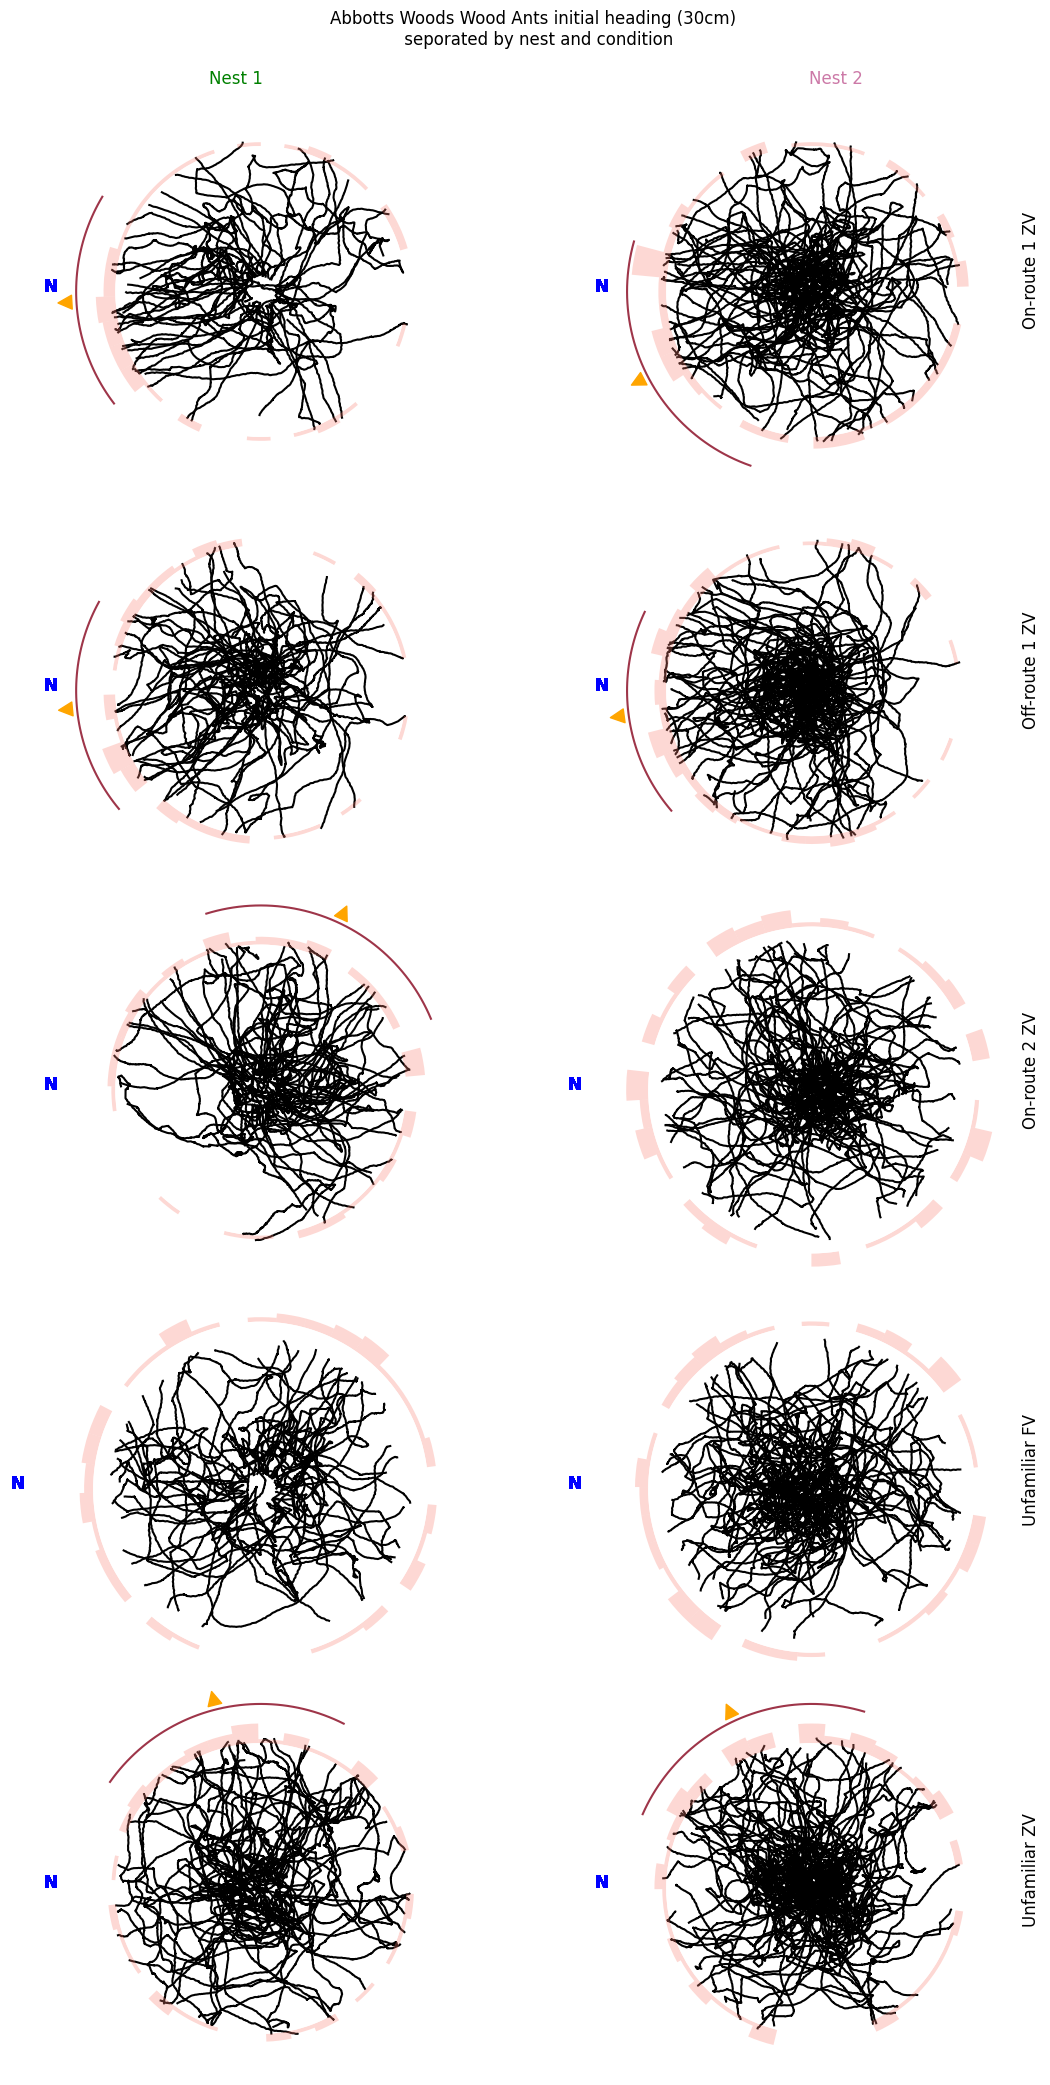

In [212]:
multiTrackplot3(anttracks, Conditions_shared, savename="CommonConditions")

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  On-route 1 ZV   max R 289.82661491299103
NewNest  On-route 1 ZV   max R 289.96544563507746
Wigwam  On-route 1B ZV   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  On-route 1B ZV   max R 289.92159976798223
Wigwam  Plus 3m ZV   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  Plus 3m ZV   max R 288.0827167971377
Wigwam  Route 0m ZV   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  Route 0m ZV   max R 289.7934862296062


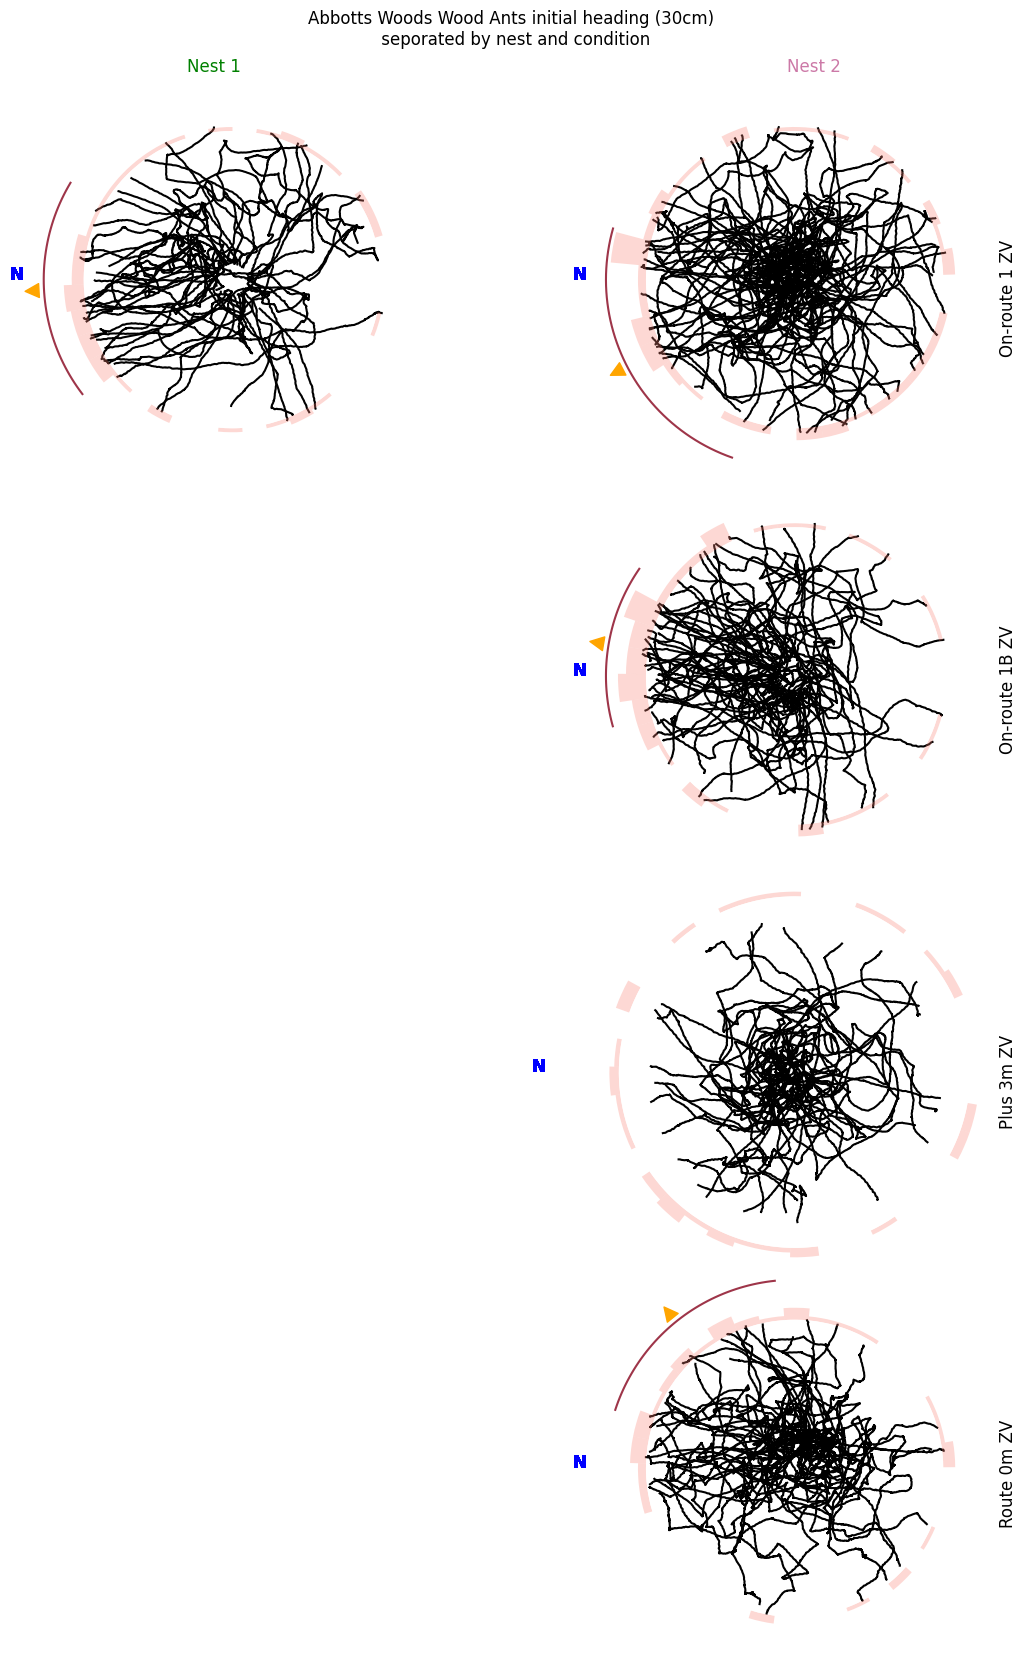

In [213]:
multiTrackplot3(anttracks, conditions_OR1, figsize=(15, 16), row_buffer=-0.02, savename="OR1Conditions")

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  Unfamiliar ZV   max R 289.9454477813641
NewNest  Unfamiliar ZV   max R 289.9766749587379
Wigwam  Unfamiliar ZV 2   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  Unfamiliar ZV 2   max R 289.91722635789006
Wigwam  Unfamiliar ZV 3   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  Unfamiliar ZV 3   max R 289.9650020145473
Wigwam  Unfamiliar FV   max R 289.9734975416451
NewNest  Unfamiliar FV   max R 289.99170981660507


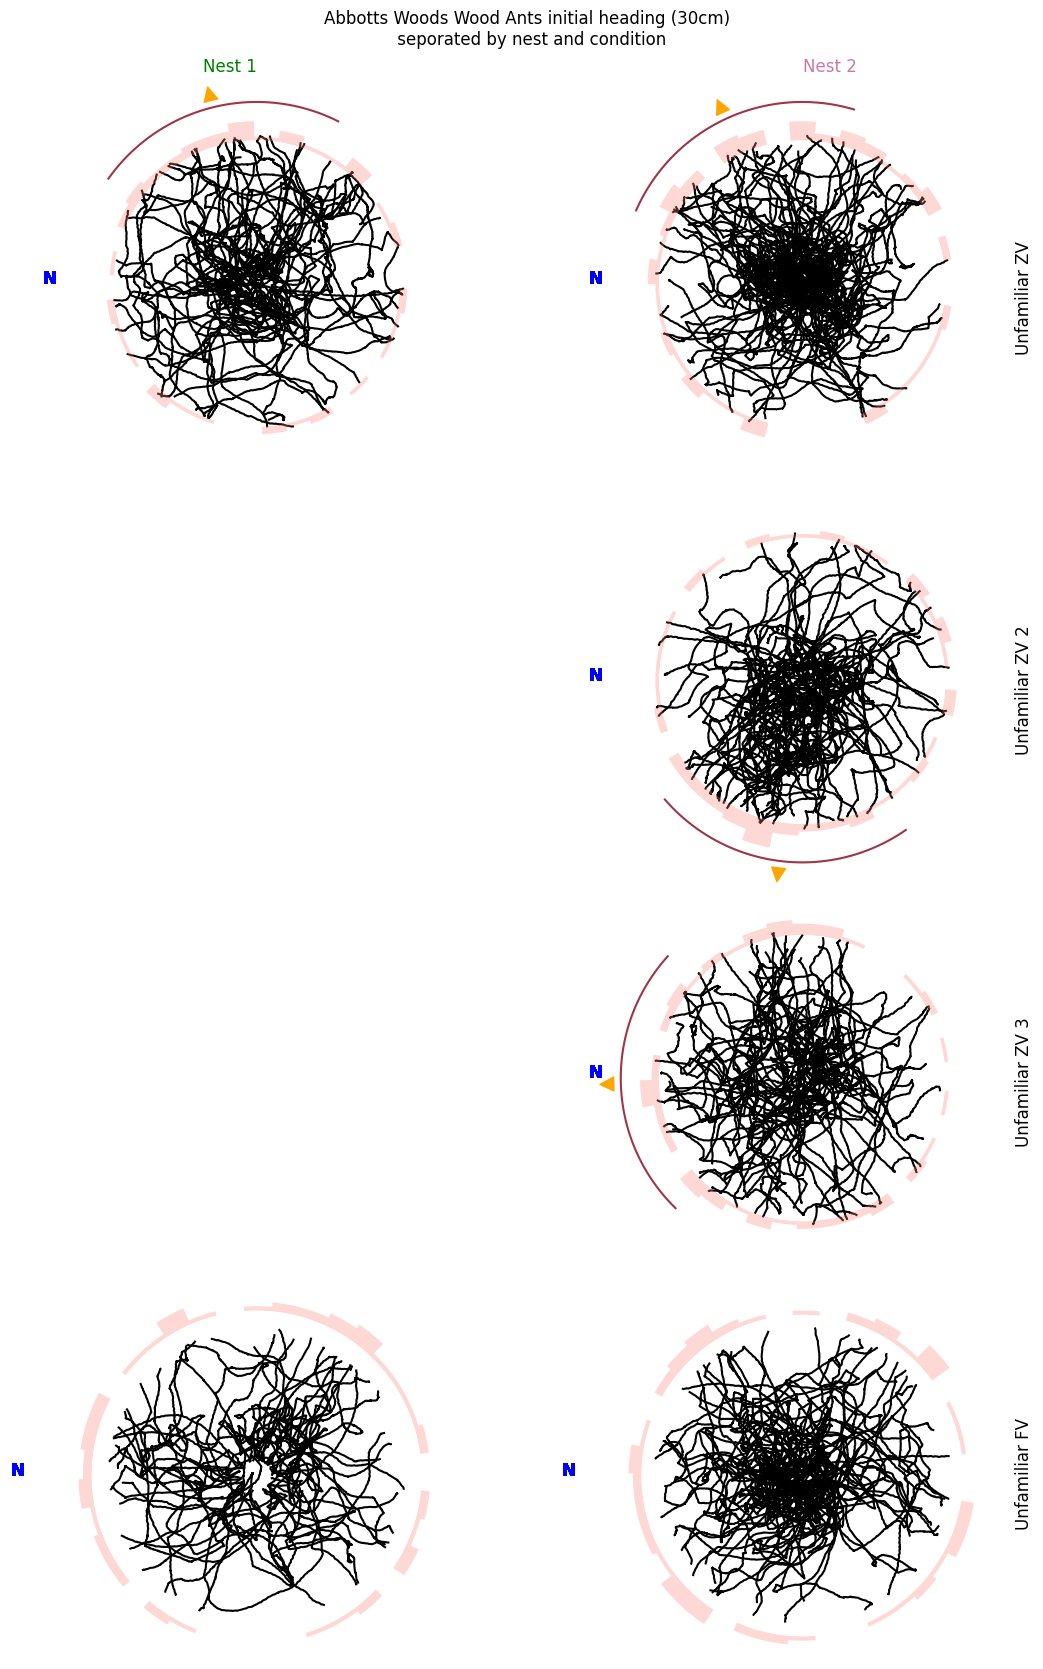

In [214]:
multiTrackplot3(anttracks, condistions_distant, figsize=(15, 16), row_buffer=-0.02, savename="DistantConditions")

# checking the gridspec structure

In [183]:
#             f = create_Overlayed_polar_plot3(df, cond, nest, title="")
from scipy.interpolate import interp1d
def create_Overlayed_polar_plottest(fig, GS,i, j,numrows, numcols, df_coordinates, condition, nest, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # create plot base
    i += 1
    #j += 1
    #print("2*i +j", (2*i +j))
    #print("(2*i +j)-1", (2*i +j)-2)
    index =(2*i +j)-2 #i+j +1#- 1 # get rows

    #print(f" i {i},     j {j}     index {index}")

    #axarr = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.6,.6],
    #ax2 = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.8,.8],
    axarr = fig.add_subplot(GS[index], projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.6,.6],
    ax2 = fig.add_subplot(GS[index], projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.8,.8],
    
    #print("axarr Size ",axarr.shape())
    #print("ax2 Size ",ax2.shape())
    
    ax2.set_rorigin(-260) # -70  -200
    annotation_offset = 43
    alphaval = 1 # 0.1
    #df_coordinates['ID'] = df_coordinates['ID'].astype('str')

    
    #longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    #cart_final_heading_list = []
    max_r = 0
    #print(np.unique(df_coordinates['Nest']))
    dfsubset = df_coordinates[(df_coordinates['Nest']==nest) & (df_coordinates['Condition']== condition)]
    #print("checking for DF")
    #print(dfsubset.head(1))
    
    
    ids = np.unique(dfsubset['ID'])
    #print(len(ids))
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)
        
    """if dfsubset.empty:
        #axarr.imshow('Alph.jpg')
        axarr.plot()
        #axarr.grid(False)
        axarr.set_ylim(0, 360)"""
    
    for id in ids:

        newdf = dfsubset[dfsubset['ID']== id]
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        theta, r = cart2pola(_x, _y)
        # trim the track between 3 and 29cm inclusive
        if max(r) >290:
            distBigger29 = np.where(r>290) # all the points the track touched 290
            lastpoint = distBigger29[0][-1] # last point before track crossed over
        else:
            lastpoint = len(r) # if track ends before 290 reached
        if max(r)>30:
            distBigger20 = np.where(r>30) # All the points the track was over 30 (3 cm)
            firstPoint = distBigger20[0][0] # first point the track crossed over to 30
        else:
            firstPoint = 0
        x_cut = _x[firstPoint: lastpoint]
        y_cut = _y[firstPoint: lastpoint]

        
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        dx = dx_[firstPoint: lastpoint]
        dy = dy_[firstPoint: lastpoint]
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)
            
        theta, r = cart2pola(x_cut, y_cut)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        #scatter2 = axarr.plot(theta, r, alpha=alphaval, color='k')
        #axarr.grid(False)
        axarr.set_ylim(0, 360)
        nestDir = np.radians(180)
        ax2.annotate('N', xy=(nestDir, annotation_offset*3), xytext=(nestDir,annotation_offset*3), color='blue', fontsize =12, weight='bold', annotation_clip=False) # plot Nest position (N)

    print(f"{nest}  {condition}   max R {max_r}")
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array)
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        var_heading_theta = scipy.stats.circvar(final_heading_array)
        std_heading_theta = scipy.stats.circstd(final_heading_array)

        varpointstart = mean_heading_theta-var_heading_theta
        varpointend =  mean_heading_theta+var_heading_theta
        
        curve_x = np.linspace(varpointstart,varpointend)#
        curve_y = interp1d((varpointstart,varpointend), [70, 70])(curve_x) # #[35, 35]

        ax2.plot(curve_x, curve_y, color= '#9E3549') # plot the variance arch
        ax2.annotate("", xy=(mean_heading_theta,annotation_offset+65), xytext=(mean_heading_theta, annotation_offset+55), arrowprops=dict(arrowstyle='simple', color='orange', mutation_scale=20), annotation_clip=False) # plot mean arrow

    # Histogram of final headings
    angles_finalHeadings = np.deg2rad((np.rad2deg(np.array(final_heading_list))) % 360) # shifting the angles so the bins cover -5 to +5
    histn, histbins = np.histogram(angles_finalHeadings, bins=36)#36
    histwidths = np.diff(histbins)
    histrad = histn *7#3 # scale up the hist for visability
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]

    #ax2.grid(visible=False)
    #ax2.grid(False, which='both')
    #print("axarr Size ",axarr.shape())
    #print("ax2 Size ",ax2.shape())

    #axarr.set_yticklabels([])
    #axarr.set_xticklabels([])
    #ax2.set_yticklabels([])
    #ax2.set_xticklabels([])
    #ax2.axis('off')
    #axarr.axis('off')
    axarr.set_ylim([0,290])
    
    plt.tight_layout()


In [184]:
def multiTrackplot_test(df, conditions:list, w_space = -0.45, h_space=1.01, figsize=(15, 20), row_buffer = -0.07): #-0.45, 0.1

    df['ID'] == df['ID'].astype('str')
    numrows = len(conditions)
    numcols = 2
    

    fig = plt.figure(figsize=figsize)
    GS = gridspec.GridSpec(numrows, numcols, width_ratios = np.ones(numcols), height_ratios=np.ones(numrows)) #  rows, cols
    print("Fig Size ",fig.get_size_inches())
    nests = np.unique(df['Nest'].astype(str))
    print(nests)
    nests = [nests[1], nests[0]]
    print(nests)
    for i in range(numrows):
        for j in range(numcols):
            cond = conditions[i]
            nes = nests[j]
            #print(f" I {i}  cond {cond}          J {j}  nest {nes}  ")
            create_Overlayed_polar_plottest(fig, GS, i, j,numrows, numcols,  df, cond, nes, title="")

    fig.text(0.30, 1.01, "Nest 1", ha='center', va='top', color= '#008000', fontsize =12)
    fig.text(0.70, 1.01, "Nest 2", ha='center', va='top', color= '#CC79A7', fontsize =12)

    #row_buffer = -0.07 # row headers
    for i, c in enumerate(conditions):
        y_pos = 0.84 - (i * (0.9/ numrows))
        fig.text(0.83, y_pos-row_buffer, c, rotation=90, va='center', ha='center', fontsize =12)
        row_buffer += 0.02

    
    #fig.set_size_inches(15, 25)
    fig.suptitle(f"Abbotts Woods Wood Ants initial heading (30cm) \n seporated by nest and condition", fontsize=12,  y=1.04)#0.99
    #fig.tight_layout(rect=[0,0,1, 0.99])
    #fig.savefig("initHeadingsMultiploth3_0825.eps", format='eps', dpi=500)
    #fig.savefig("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/AntBotFigs/testingColours_abbotsTracks.jpg", format='jpg', bbox_inches="tight", dpi=500) # bbox_extra_artists=[suptitle],
    #plt.legend()
    fig.show()

# save as svg for non-compressing scalable figures

Fig Size  [15. 16.]
['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  Unfamiliar ZV   max R 289.9454477813641
NewNest  Unfamiliar ZV   max R 289.9766749587379
Wigwam  Unfamiliar ZV 2   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  Unfamiliar ZV 2   max R 289.91722635789006
Wigwam  Unfamiliar ZV 3   max R 0
NewNest  Unfamiliar ZV 3   max R 289.9650020145473
Wigwam  Unfamiliar FV   max R 289.9734975416451
NewNest  Unfamiliar FV   max R 289.99170981660507


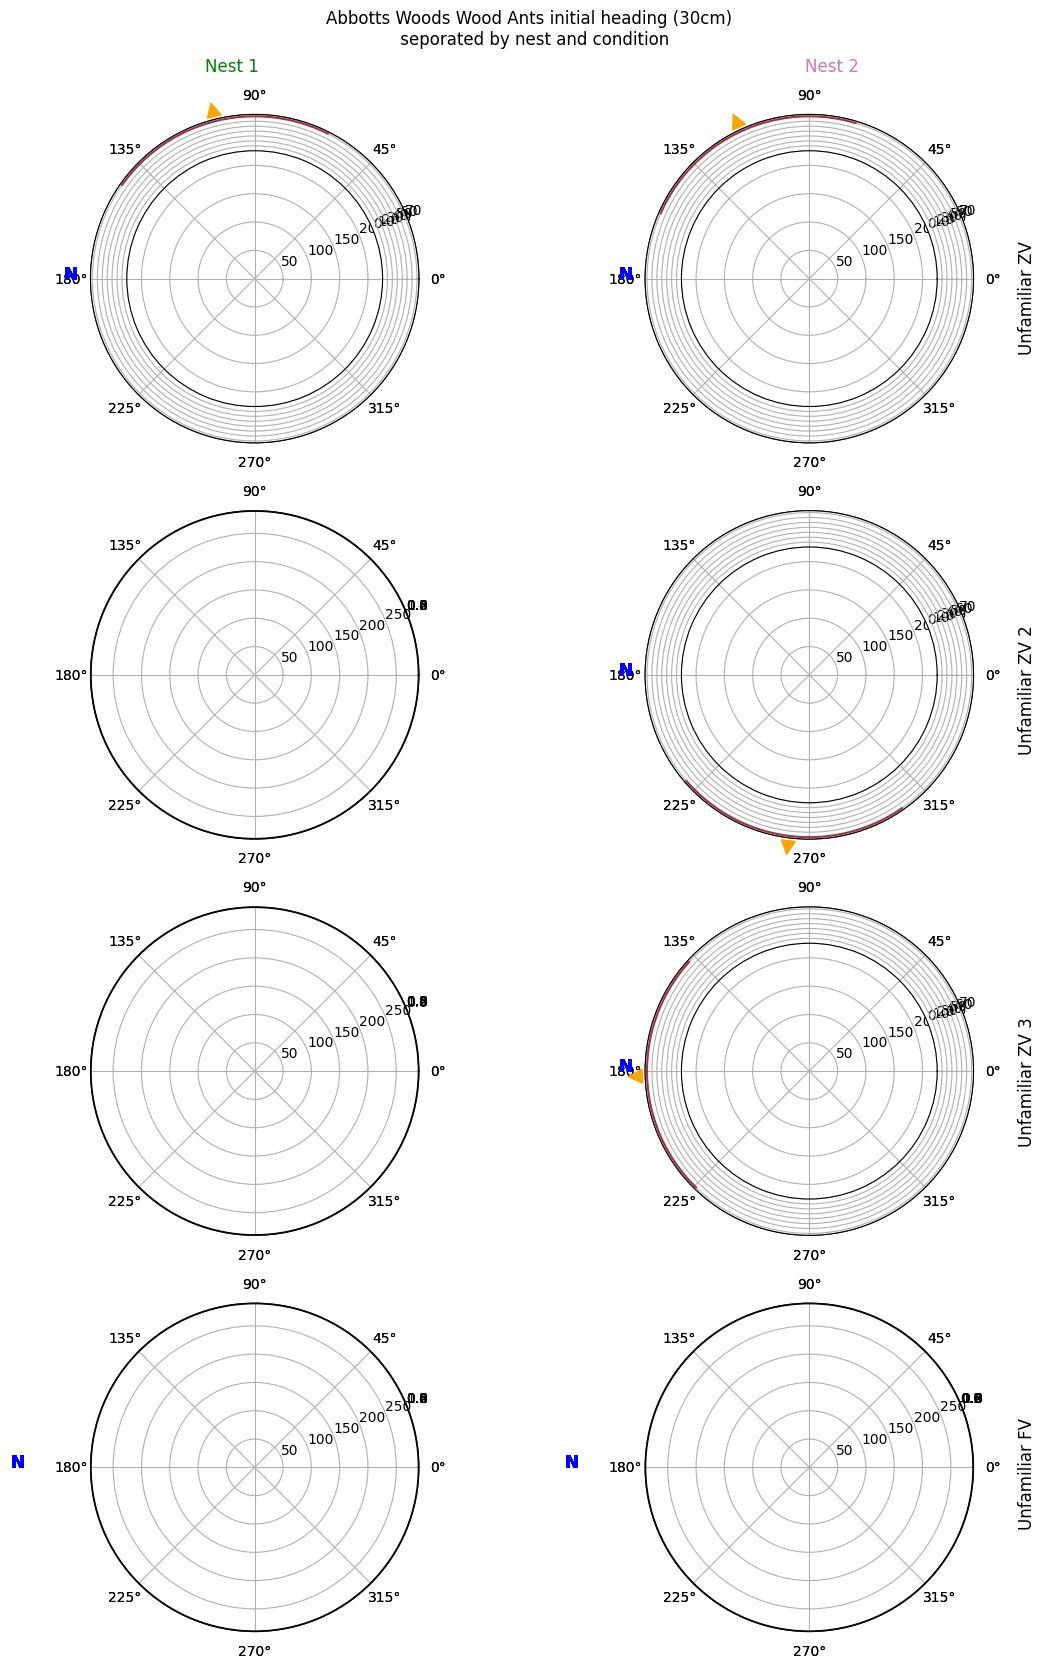

In [185]:
multiTrackplot_test(anttracks, condistions_distant, figsize=(15, 16), row_buffer=-0.02)

Fig Size  [15. 16.]
['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  On-route 1 ZV   max R 289.82661491299103
NewNest  On-route 1 ZV   max R 289.96544563507746
Wigwam  On-route 1B ZV   max R 0


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


NewNest  On-route 1B ZV   max R 289.92159976798223
Wigwam  Plus 3m ZV   max R 0
NewNest  Plus 3m ZV   max R 288.0827167971377
Wigwam  Route 0m ZV   max R 0
NewNest  Route 0m ZV   max R 289.7934862296062


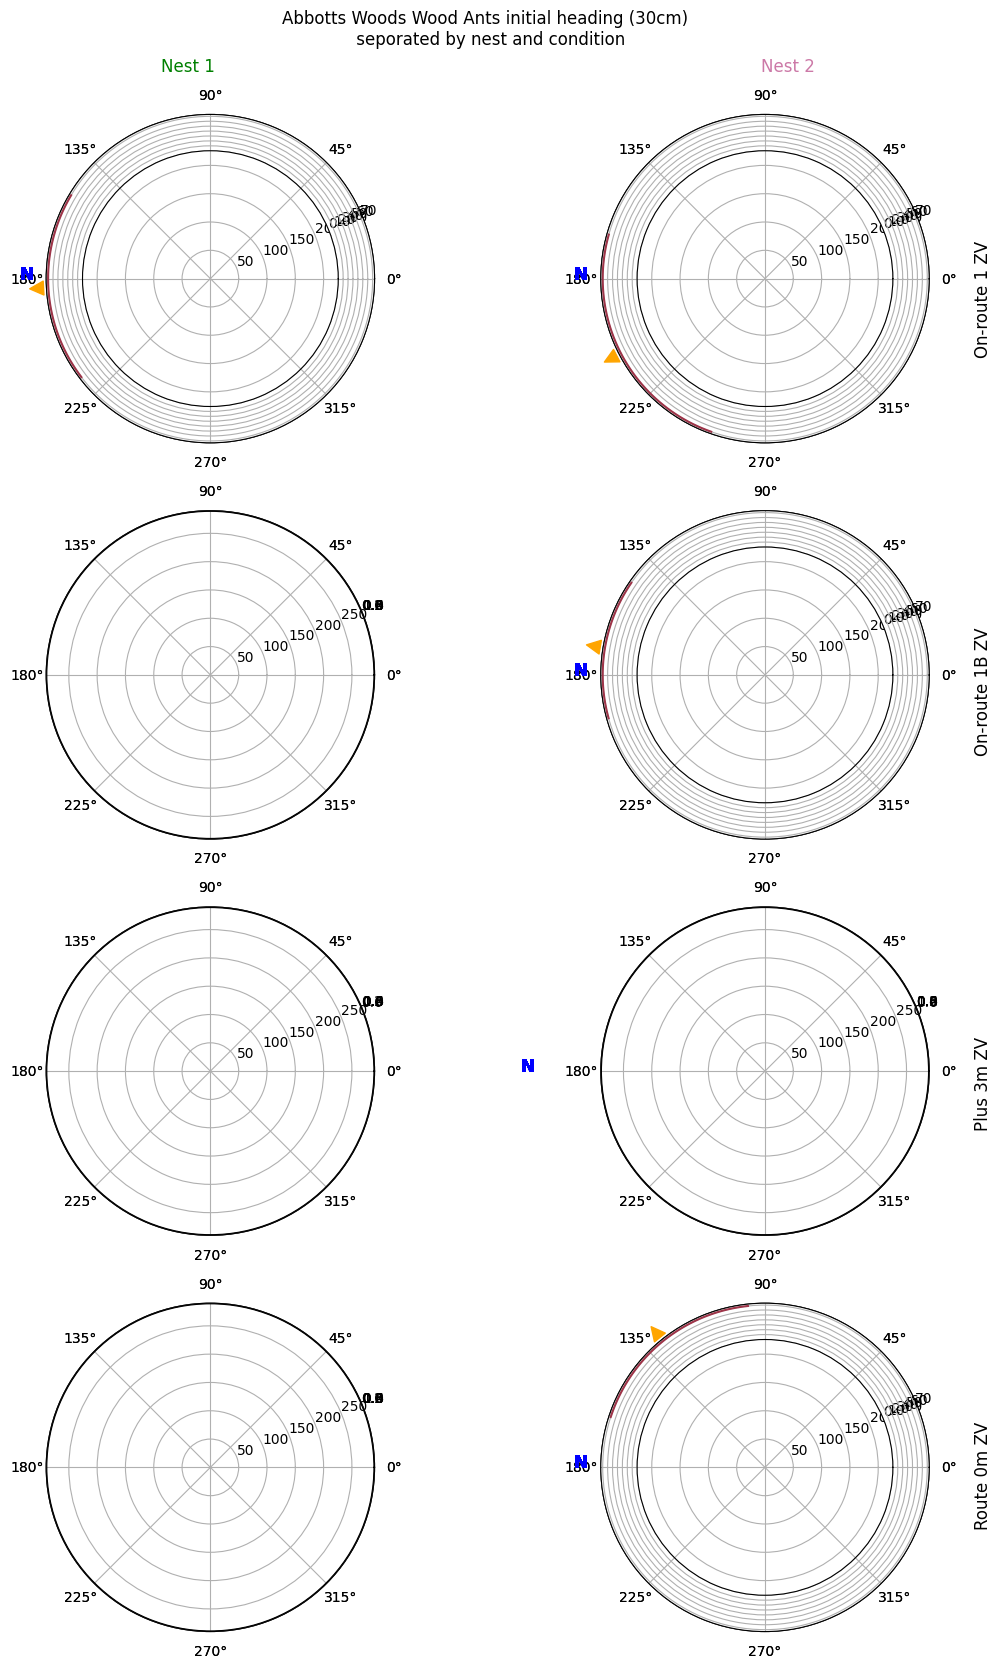

In [186]:
multiTrackplot_test(anttracks, conditions_OR1, figsize=(15,16), row_buffer=-0.019)

Fig Size  [15. 20.]
['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
Wigwam  On-route 1 ZV   max R 289.82661491299103
NewNest  On-route 1 ZV   max R 289.96544563507746
Wigwam  Off-route 1 ZV   max R 289.9717608554956
NewNest  Off-route 1 ZV   max R 289.9941233239155
Wigwam  On-route 2 ZV   max R 289.86441534397665
NewNest  On-route 2 ZV   max R 289.9948121440652
Wigwam  Unfamiliar FV   max R 289.9734975416451
NewNest  Unfamiliar FV   max R 289.99170981660507
Wigwam  Unfamiliar ZV   max R 289.9454477813641
NewNest  Unfamiliar ZV   max R 289.9766749587379


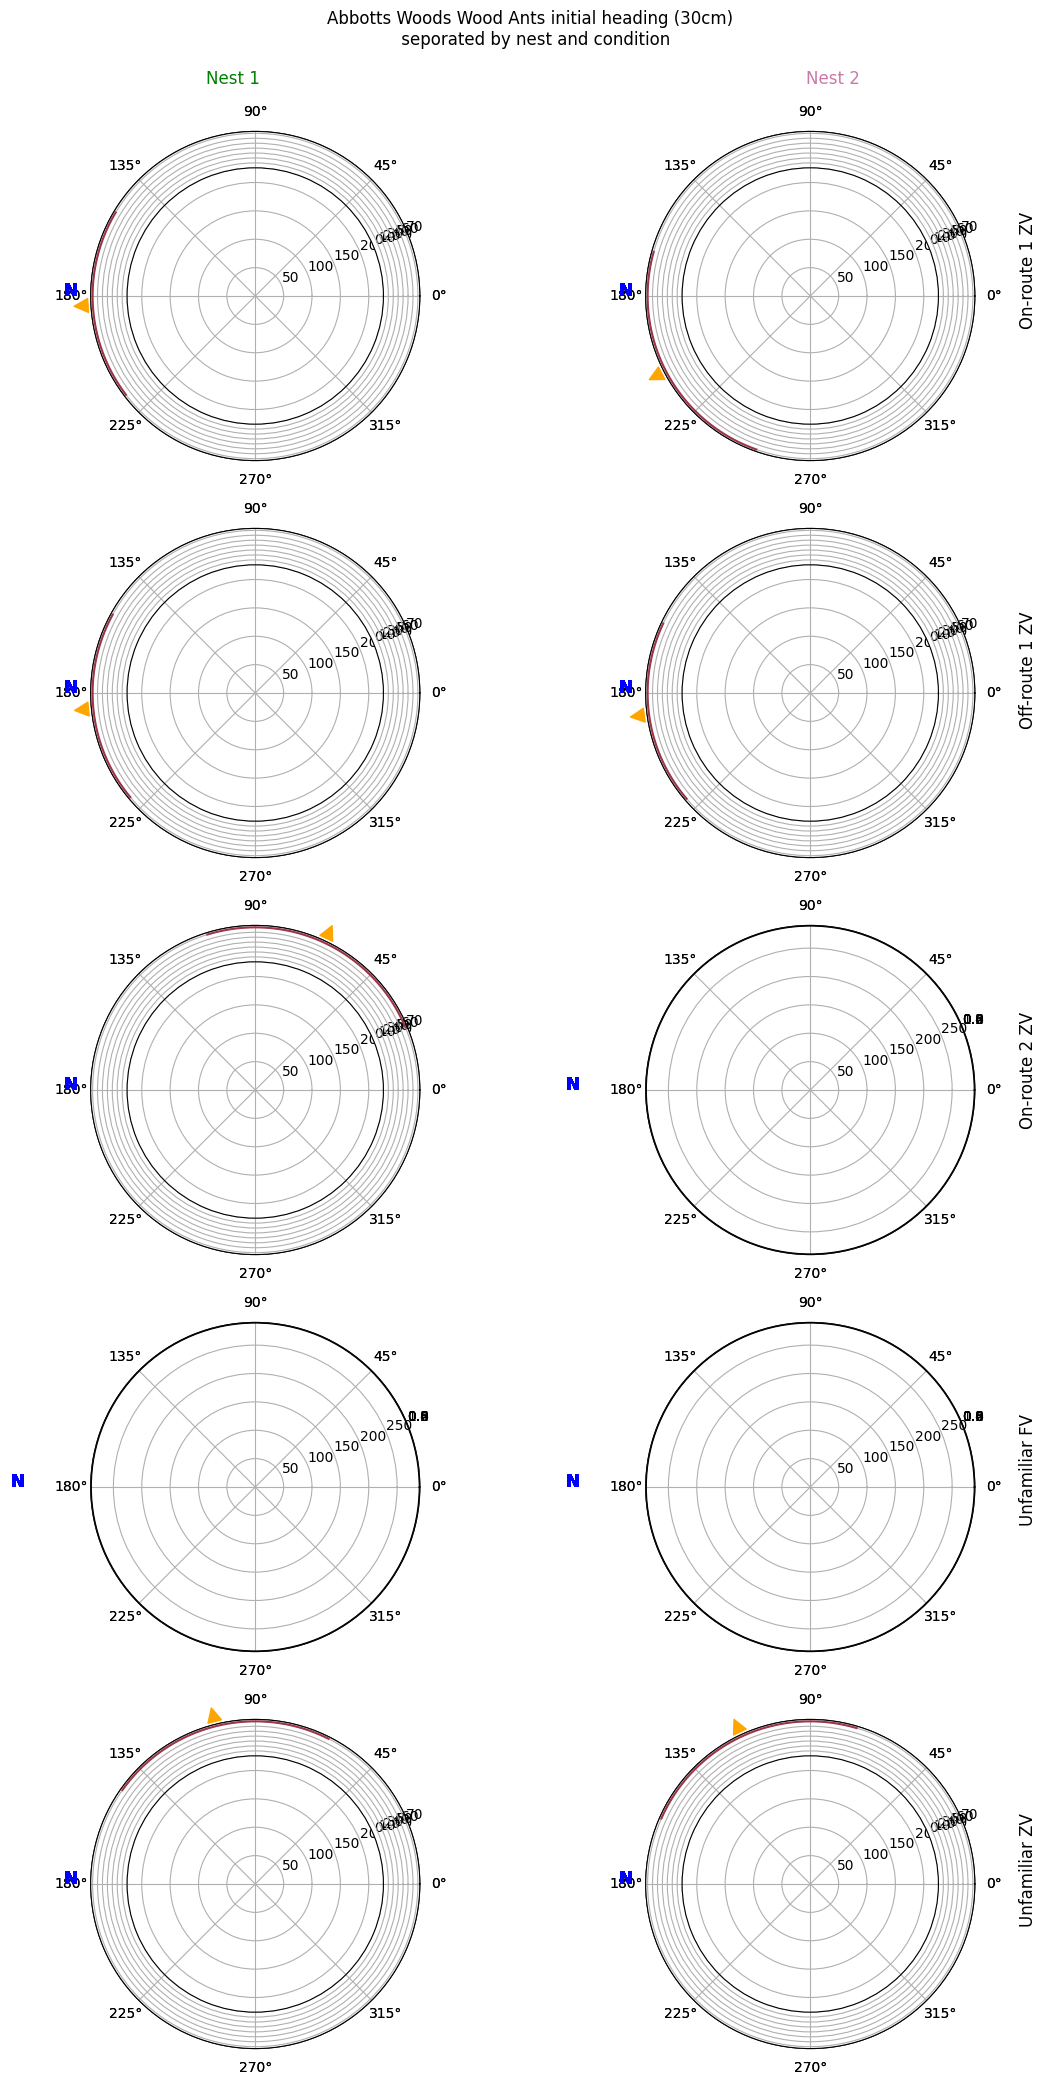

In [187]:
multiTrackplot_test(anttracks, Conditions_shared) 